# Question 4 : Image Segmentation

In [359]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import hashlib
import cv2
from sklearn.preprocessing import StandardScaler

In [360]:
def _add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

def print_separator() -> None:
    print("\n" + "="*50 + "\n")

In [361]:
username = "siddarth.g"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
print("Seed value : ", seed)
print_separator()

Seed value :  2198587646




In [362]:
class GMM:
    """
    Gaussian Mixture Model implementation using Expectation-Maximization algorithm
    """
    
    def __init__(self, k, max_iters=150, tol=1e-1, random_state=42):
        """
        Initialize Gaussian Mixture Model
        
        Parameters:
            k (int): Number of clusters/components
            max_iters (int): Maximum number of iterations for EM algorithm
            tol (float): Convergence tolerance
            random_state (int): Random seed for reproducibility
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.iteration_history = []  # Store parameters for each iteration
        
    def fit(self, X, orgnl_shape=(787,1000)):
        """
        Implements the Expectation-Maximization (EM) algorithm to determine optimal parameters
        
        Parameters:
            X (array-like): Training data of shape (n_samples, n_features)
        
        Returns:
            self: Returns the instance itself
        """
        np.random.seed(self.random_state)
        self.X = X
        self.n_samples, self.n_features = X.shape

        segment_colors = [
            [0, 0, 255],    # Blue
            [0, 255, 0],    # Green
            [255, 0, 0],    # Red
        ]
        
        # Initialize parameters
        self._initialize_parameters()

        # Store log likelihood history for convergence monitoring
        self.log_likelihood_history = []
        # Initialize iteration history storage
        self.iteration_history = []
        
        for iteration in range(self.max_iters):
            # E-step: Calculate responsibilities (membership probabilities)
            responsibilities = self._expectation_step()
            
            # M-step: Update parameters
            self._maximization_step(responsibilities)

            # Calculate current log likelihood
            current_log_likelihood = self.getLogLikelihood()
            # print(f"Iteration {iteration + 1}, Log-Likelihood: {current_log_likelihood:.4f}")
            self.log_likelihood_history.append(current_log_likelihood)
            
            # Store current iteration parameters and predictions
            labels = np.argmax(responsibilities, axis=1)
            # Calculate per-sample average log likelihood
            per_sample_likelihood = current_log_likelihood / self.n_samples
            iteration_data = {
                'iteration': iteration,
                'likelihood': per_sample_likelihood,
                'segmented_image': np.array([segment_colors[label] for label in labels]).reshape(orgnl_shape),
                'likelihoods_so_far': [ll / self.n_samples for ll in self.log_likelihood_history]
            }
            self.iteration_history.append(iteration_data)

            # Check for convergence
            if iteration > 0:
                if abs(self.log_likelihood_history[-1] - self.log_likelihood_history[-2]) < self.tol:
                    print(f"Converged after {iteration + 1} iterations")
                    break
        
        return self
    
    def _initialize_parameters(self):
        """
        Initialize GMM parameters (weights, means, covariances)
        """
        # Initialize mixing coefficients (weights) uniformly
        self.weights = np.ones(self.k) / self.k
        
        # Initialize means by sampling k distinct data points for better stability
        idx = np.random.choice(self.n_samples, self.k, replace=False)
        self.means = self.X[idx].astype(float).copy()
        
        # Initialize covariances using the overall data covariance with small regularization
        data_cov = np.cov(self.X, rowvar=False)
        if data_cov.ndim == 0:
            data_cov = np.eye(self.n_features)
        reg = 1e-6
        base_cov = data_cov + np.eye(self.n_features) * reg
        self.covariances = np.array([base_cov.copy() for _ in range(self.k)])
    
    def _expectation_step(self):
        """
        E-step: Calculate responsibilities (posterior probabilities)
        
        Returns:
            array: Responsibility matrix of shape (n_samples, k)
        """
        responsibilities = np.zeros((self.n_samples, self.k))
        
        for k in range(self.k):
            # Calculate probability density for each component
            try:
                responsibilities[:, k] = self.weights[k] * self._multivariate_normal(self.X, self.means[k], self.covariances[k])
            except np.linalg.LinAlgError:
                # Handle singular covariance matrix by adding jitter
                self.covariances[k] += np.eye(self.n_features) * 1e-6
                responsibilities[:, k] = self.weights[k] * self._multivariate_normal(self.X, self.means[k], self.covariances[k])
        
        # Normalize responsibilities with epsilon to avoid division by zero
        responsibilities_sum = responsibilities.sum(axis=1, keepdims=True)
        responsibilities_sum = np.clip(responsibilities_sum, 1e-300, None)
        responsibilities /= responsibilities_sum
        
        return responsibilities

    # Custom implementation of multivariate normal PDF
    # def _multivariate_normal(self, x, mean, cov):
    #     """
    #     Compute the probability density function of a multivariate normal distribution.
    #     """
    #     x = np.atleast_2d(x)
    #     if x.shape[0] == 1 and x.shape[1] != len(mean):
    #         x = x.T
        
    #     diff = x - mean
        
    #     try:
    #         inv_cov = np.linalg.inv(cov)
    #         det_cov = np.linalg.det(cov)
    #     except np.linalg.LinAlgError:
    #         # Add regularization and try again
    #         cov = cov + np.eye(len(mean)) * 1e-6
    #         inv_cov = np.linalg.inv(cov)
    #         det_cov = np.linalg.det(cov)
        
    #     # Ensure determinant is positive
    #     if det_cov <= 0:
    #         det_cov = 1e-10
        
    #     n = len(mean)
    #     norm_const = 1.0 / np.sqrt((2 * np.pi) ** n * det_cov)
        
    #     exponents = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
        
    #     # Clip exponents to prevent numerical issues
    #     exponents = np.clip(exponents, -500, 500)
        
    #     return norm_const * np.exp(exponents)
    def _multivariate_normal(self, x, mean, cov):
        """
        Compute the probability density function of a multivariate normal distribution.
        
        Parameters:
        x (array-like): Data points of shape (n_samples, n_features) or (n_features,)
        mean (array-like): Mean vector of shape (n_features,)
        cov (array-like): Covariance matrix of shape (n_features, n_features)
        
        Returns:
        array: Probability densities for each data point
        """
        n = mean.shape[0]
        
        # Handle both single point and multiple points
        x = np.atleast_2d(x)
        if x.shape[0] == 1 and x.shape[1] != n:
            x = x.T  # Transpose if it's a single point passed as row vector
        
        diff = x - mean
        
        try:
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)
        except np.linalg.LinAlgError:
            # In case of singular matrix, add small regularization
            cov = cov + np.eye(n) * 1e-6
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)
        
        # Ensure determinant is positive
        if det_cov <= 0:
            det_cov = 1e-10
        
        norm_const = 1.0 / np.sqrt((2 * np.pi) ** n * det_cov)
        
        # Calculate the quadratic form for each data point
        if diff.ndim == 1:
            # Single point case
            exponent = -0.5 * diff @ inv_cov @ diff.T
        else:
            # Multiple points case
            exponents = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
        
        return norm_const * np.exp(exponents)
    
    def _maximization_step(self, responsibilities):
        """
        M-step: Update parameters based on responsibilities
        
        Parameters:
            responsibilities (array): Responsibility matrix from E-step
        """
        # Calculate effective number of points assigned to each component
        Nk = responsibilities.sum(axis=0)
        
        # Update mixing coefficients (weights)
        total = Nk.sum()
        if total <= 0:
            # Fallback to uniform if something went numerically wrong
            self.weights = np.ones(self.k) / self.k
        else:
            self.weights = Nk / total
        
        # Update means
        for k in range(self.k):
            if Nk[k] > 0:
                self.means[k] = np.sum(responsibilities[:, k:k+1] * self.X, axis=0) / Nk[k]
        
        # Update covariances with small diagonal regularization
        for k in range(self.k):
            if Nk[k] > 0:
                diff = self.X - self.means[k]
                self.covariances[k] = np.sum(responsibilities[:, k:k+1, np.newaxis] * (diff[:, :, np.newaxis] @ diff[:, np.newaxis, :]),
                                             axis=0) / Nk[k]
                # Regularize to prevent singular matrices
                self.covariances[k] += np.eye(self.n_features) * 1e-6
    
    def getMembership(self):
        """
        Returns the membership values for each sample in the dataset
        
        Returns:
            array: Membership probability matrix of shape (n_samples, k)
        """
        return self._expectation_step()
    
    def getLogLikelihood(self):
        """
        Returns the overall log likelihood of the entire dataset under current model parameters
        
        Returns:
            float: Log-likelihood of the data
        """
        eps = 1e-300
        
        # Vectorized computation of likelihood for all samples
        # Compute likelihood for each component for all samples at once
        sample_likelihoods = np.zeros(self.n_samples)
        
        for k in range(self.k):
            try:
                # Compute PDF for all samples for component k
                pdf_vals = self._multivariate_normal(self.X, self.means[k], self.covariances[k])
                sample_likelihoods += self.weights[k] * pdf_vals
            except np.linalg.LinAlgError:
                # In rare cases, fall back to a tiny value for all samples
                sample_likelihoods += self.weights[k] * 1e-6
        
        # Ensure no likelihood is zero to avoid log(0)
        sample_likelihoods = np.maximum(sample_likelihoods, eps)
        
        # Sum log likelihoods for all samples
        log_likelihood = np.sum(np.log(sample_likelihoods))
        
        return log_likelihood
    
    def drawLikelihood(self):
        """
        Draws the plot of likelihood vs iterations for the number of clusters used
        """
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(self.log_likelihood_history) + 1), self.log_likelihood_history, 
                'b-', linewidth=2, marker='o', markersize=4)
        plt.title(f'Likelihood vs Iterations (k={self.k})', fontsize=14)
        plt.xlabel('Iteration', fontsize=12)
        plt.ylabel('Log-Likelihood', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        _add_username("siddarth.g")
        plt.show()
        
        print(f"Final log likelihood: {self.log_likelihood_history[-1]:.4f}")
        print(f"Converged in {len(self.log_likelihood_history)} iterations")
    
    def predict(self, X):
        """
        Predict cluster assignments for new data points
        
        Parameters:
            X (array-like): Data points to predict
        
        Returns:
            array: Predicted cluster labels
        """
        responsibilities = np.zeros((X.shape[0], self.k))
        
        for k in range(self.k):
            try:
                responsibilities[:, k] = self.weights[k] * self._multivariate_normal(X, self.means[k], self.covariances[k])
            except np.linalg.LinAlgError:
                # Handle singular covariance matrix
                self.covariances[k] += np.eye(self.n_features) * 1e-6
                responsibilities[:, k] = self.weights[k] * self._multivariate_normal(X, self.means[k], self.covariances[k])
        
        # Normalize to get soft assignments then argmax for labels
        denom = responsibilities.sum(axis=1, keepdims=True)
        denom = np.clip(denom, 1e-300, None)
        responsibilities /= denom
        return np.argmax(responsibilities, axis=1)
    
    def getIterationHistory(self):
        """
        Returns the stored iteration history containing parameters and predictions for each iteration
        
        Returns:
            list: List of dictionaries containing iteration data
        """
        return self.iteration_history

In [363]:
class ImageSegmentationGMM:
    def __init__(self, n_components=3, rand_state=42):
        """
        Initialize the Image Segmentation GMM
        
        Parameters:
            n_components (int): Number of segments (Land, Water, Vegetation)
            rand_state (int): Random state for reproducibility
        """
        self.n_components = n_components
        self.gmm = None
        self.original_shape = None
        self.segmented_image = None
        self.random_state = rand_state
        self.likelihoods = []
        self.scaler = StandardScaler()  # For scaling RGB values
        
    def load_image(self, image_path):
        """
        Load and preprocess satellite image with standardization
        
        Parameters:
            image_path (str): Path to the satellite image
            
        Returns:
            numpy.ndarray: Flattened and scaled image data
        """
        # Load image
        image = Image.open(image_path)
        image_array = np.array(image)
        print(f"Loaded image with shape: {image_array.shape}")

        # Store original shape for reconstruction
        self.original_shape = image_array.shape
        
        # Flatten to (n_pixels, 3) for RGB
        flattened_data = image_array.reshape(-1, 3).astype(np.float32)
        print(f"Flattened image data shape: {flattened_data.shape}")
        
        # Standardize RGB values for faster convergence
        scaled_data = self.scaler.fit_transform(flattened_data)
        print(f"Scaled data - Mean: {scaled_data.mean(axis=0)}, Std: {scaled_data.std(axis=0)}")
        
        # return scaled_data
        return flattened_data
    
    def fit_gmm(self, data):
        """
        Fit GMM to the flattened image data
        
        Parameters:
            data (numpy.ndarray): Flattened image data
        """
        print("Using custom GMM from Q3")
        # Custom GMM class from Q3
        self.gmm = GMM(k=self.n_components, random_state=self.random_state, max_iters=150, tol=1e-1)
        self.gmm.fit(data, orgnl_shape=self.original_shape)
    
    def segment_image(self, data):
        """
        Segment the image using the fitted GMM
        
        Parameters:
            data (numpy.ndarray): Flattened image data
            
        Returns:
            numpy.ndarray: Segmented image
        """
        # Get cluster assignments
        memberships = self.gmm.getMembership()
        labels = np.argmax(memberships, axis=1)

        # Create segmented image with distinct colors
        segment_colors = [
            [0, 0, 255],    # Blue
            [0, 255, 0],    # Green
            [255, 0, 0],    # Red
        ]
        
        # Create RGB segmented image
        segmented_flat = np.array([segment_colors[label] for label in labels])
        segmented_image = segmented_flat.reshape(self.original_shape)
        
        self.segmented_image = segmented_image
        return segmented_image
    
    def get_likelihood_history(self):
        """
        Get the likelihood history during fitting
        """
        return self.gmm.likelihoods

In [ ]:
class DynamicVisualizationVideo:
    def __init__(self, gmm_segmenter):
        """
        Initialize dynamic visualization video generator
        
        Parameters:
            gmm_segmenter: Instance of ImageSegmentationGMM
        """
        self.gmm_segmenter = gmm_segmenter
        self.video_writer = None
    
    def create_video_frame(self, original_image, iteration_data, frame_size=(1200, 400)):
        """
        Create a single video frame with three panels
        
        Parameters:
            original_image: Original satellite image
            iteration_data: Data for current iteration
            frame_size: Size of the output frame
            
        Returns:
            numpy.ndarray: Video frame
        """
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
        
        # Panel 1: Original image
        ax1.imshow(original_image)
        ax1.set_title('Original Satellite Image')
        ax1.axis('off')
        
        # Panel 2: Current segmentation
        ax2.imshow(iteration_data['segmented_image'])
        ax2.set_title(f'Segmentation - Iteration {iteration_data["iteration"]}')
        ax2.axis('off')
        
        # Panel 3: Likelihood vs iteration plot
        ax3.plot(range(len(iteration_data['likelihoods_so_far'])), 
                iteration_data['likelihoods_so_far'], 'b-o', markersize=4)
        ax3.set_xlabel('Iteration')
        ax3.set_ylabel('Average Log-Likelihood')
        ax3.set_title('Convergence Progress')
        ax3.grid(True, alpha=0.3)
        
        # Highlight current iteration
        if len(iteration_data['likelihoods_so_far']) > 0:
            ax3.plot(iteration_data['iteration'], 
                    iteration_data['likelihood'], 'ro', markersize=8)
        
        plt.tight_layout()
        
        # Convert matplotlib figure to numpy array
        fig.canvas.draw()
        frame = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        frame = frame[:, :, :3]  # Remove alpha channel
        plt.close(fig)
        
        return frame
    
    def generate_video(self, image_path, output_path='gmm_segmentation.mp4', fps=4):
        """
        Generate the complete dynamic visualization video
        
        Parameters:
            image_path: Path to satellite image
            output_path: Output video file path
            fps: Frames per second
        """
        # Load and process image
        data = self.gmm_segmenter.load_image(image_path)
        original_image = np.array(Image.open(image_path))
        # Get EM iteration data
        iterations_data = self.gmm_segmenter.gmm.iteration_history
        
        # Setup video writer
        first_frame = self.create_video_frame(original_image, iterations_data[0])
        height, width, _ = first_frame.shape
        
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        self.video_writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        
        print(f"Generating video with {len(iterations_data)} frames...")
        
        # Generate video frames
        for i, iter_data in enumerate(iterations_data):
            frame = self.create_video_frame(original_image, iter_data)
            # Convert RGB to BGR for OpenCV
            frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            self.video_writer.write(frame_bgr)
            
            print(f"Generated frame {i+1}/{len(iterations_data)}")
        
        # Release video writer
        self.video_writer.release()
        print(f"Video saved to: {output_path}")

=== Q4.1: Image Segmentation ===

Processing satellite_1.png...
Loaded image with shape: (767, 1000, 3)
Flattened image data shape: (767000, 3)
Scaled data - Mean: [-2.3423170e-04 -3.7847433e-06 -7.9217622e-05], Std: [0.99995744 0.999997   0.9996288 ]
Using custom GMM from Q3
Scaled data - Mean: [-2.3423170e-04 -3.7847433e-06 -7.9217622e-05], Std: [0.99995744 0.999997   0.9996288 ]
Using custom GMM from Q3
Converged after 59 iterations
Converged after 59 iterations


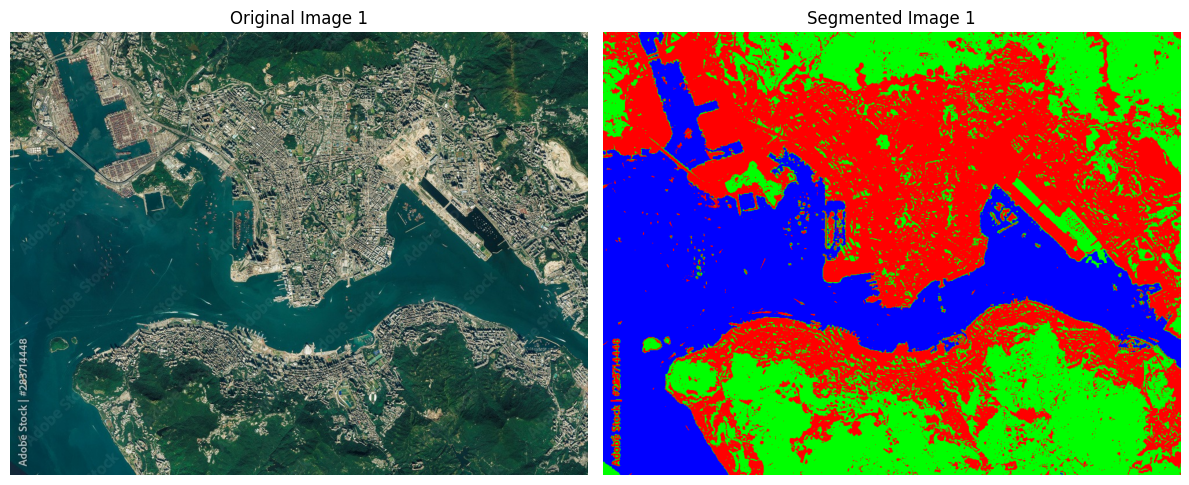


=== Q4.2: Generating Dynamic Visualization Video for Image 1 ===
Loaded image with shape: (767, 1000, 3)
Flattened image data shape: (767000, 3)
Scaled data - Mean: [-2.3423170e-04 -3.7847433e-06 -7.9217622e-05], Std: [0.99995744 0.999997   0.9996288 ]
Scaled data - Mean: [-2.3423170e-04 -3.7847433e-06 -7.9217622e-05], Std: [0.99995744 0.999997   0.9996288 ]
Generating video with 59 frames...
Generating video with 59 frames...
Generated frame 1/59
Generated frame 1/59
Generated frame 2/59
Generated frame 2/59
Generated frame 3/59
Generated frame 3/59
Generated frame 4/59
Generated frame 4/59
Generated frame 5/59
Generated frame 5/59
Generated frame 6/59
Generated frame 6/59
Generated frame 7/59
Generated frame 7/59
Generated frame 8/59
Generated frame 8/59
Generated frame 9/59
Generated frame 9/59
Generated frame 10/59
Generated frame 10/59
Generated frame 11/59
Generated frame 11/59
Generated frame 12/59
Generated frame 12/59
Generated frame 13/59
Generated frame 13/59
Generated fram

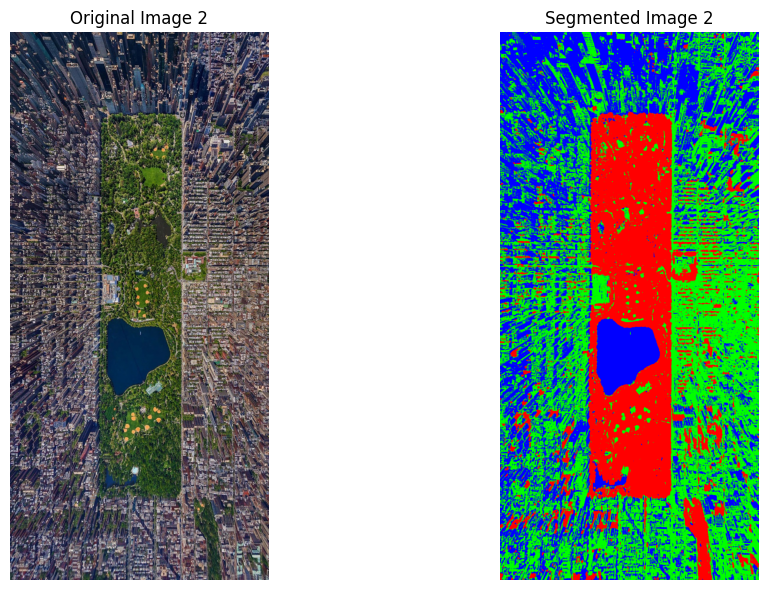


=== Q4.2: Generating Dynamic Visualization Video for Image 2 ===
Loaded image with shape: (1600, 755, 3)
Flattened image data shape: (1208000, 3)
Scaled data - Mean: [-2.1834196e-05  8.0103637e-06 -7.9543452e-06], Std: [0.9997457  0.99951565 0.9997076 ]
Scaled data - Mean: [-2.1834196e-05  8.0103637e-06 -7.9543452e-06], Std: [0.9997457  0.99951565 0.9997076 ]
Generating video with 86 frames...
Generating video with 86 frames...
Generated frame 1/86
Generated frame 1/86
Generated frame 2/86
Generated frame 2/86
Generated frame 3/86
Generated frame 3/86
Generated frame 4/86
Generated frame 4/86
Generated frame 5/86
Generated frame 5/86
Generated frame 6/86
Generated frame 6/86
Generated frame 7/86
Generated frame 7/86
Generated frame 8/86
Generated frame 8/86
Generated frame 9/86
Generated frame 9/86
Generated frame 10/86
Generated frame 10/86
Generated frame 11/86
Generated frame 11/86
Generated frame 12/86
Generated frame 12/86
Generated frame 13/86
Generated frame 13/86
Generated fra

In [365]:
# Part 4.1: Image Segmentation
print("=== Q4.1: Image Segmentation ===")

# Process two satellite images
image_paths = ['data/satellite_1.png', 'data/satellite_2.png']

for i, image_path in enumerate(image_paths):
    if not os.path.exists(image_path):
        print(f"Warning: {image_path} not found. Please provide satellite images.")
        continue
        
    print(f"\nProcessing {image_path}...")
    
    # Load and segment image
    segmenter = ImageSegmentationGMM(n_components=3, rand_state=seed)
    data = segmenter.load_image(image_path)
    segmenter.fit_gmm(data)
    segmented = segmenter.segment_image(data)
    
    # Display results
    original_image = np.array(Image.open(image_path))
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title(f'Original Image {i+1}')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(segmented)
    plt.title(f'Segmented Image {i+1}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Part 4.2: Dynamic Visualization Video
    print(f"\n=== Q4.2: Generating Dynamic Visualization Video for Image {i+1} ===")
    
    video_generator = DynamicVisualizationVideo(segmenter)
    output_video_path = f'data/gmm_segmentation_video_{i+1}.mp4'
    video_generator.generate_video(image_path, output_video_path)
    
    print(f"Video generated: {output_video_path}")